### Title: Restaurant Sales EDA, Revenue Forecasting & Business Intelligence


This notebook extends the original exploratory data analysis and predictive modeling workflow into a business intelligence foundation for BizIntel AI. It analyzes transaction patterns, calculates revenue, forecasts daily revenue, detects anomalies, and exports business-ready datasets.

## Import of the dataset

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import date
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

#Visualization Colors


/kaggle/input/datasets/rohitgrewal/restaurant-sales-data/9. Sales-Data-Analysis.csv


In [4]:
df = pd.read_csv("/kaggle/input/datasets/rohitgrewal/restaurant-sales-data/9. Sales-Data-Analysis.csv")

In [5]:
df.head()

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
0,10452,07-11-2022,Fries,3.49,573.07,Online,Gift Card,Tom Jackson,London
1,10453,07-11-2022,Beverages,2.95,745.76,Online,Gift Card,Pablo Perez,Madrid
2,10454,07-11-2022,Sides & Other,4.99,200.40,In-store,Gift Card,Joao Silva,Lisbon
3,10455,08-11-2022,Burgers,12.99,569.67,In-store,Credit Card,Walter Muller,Berlin
4,10456,08-11-2022,Chicken Sandwiches,9.95,201.01,In-store,Credit Card,Walter Muller,Berlin


In [6]:
df.tail()

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
249,10709,28-12-2022,Sides & Other,4.99,200.40,Drive-thru,Gift Card,Walter Muller,Berlin
250,10710,29-12-2022,Burgers,12.99,754.43,Drive-thru,Gift Card,Walter Muller,Berlin
251,10711,29-12-2022,Chicken Sandwiches,9.95,281.41,Drive-thru,Gift Card,Walter Muller,Berlin
252,10712,29-12-2022,Fries,3.49,630.37,Drive-thru,Gift Card,Walter Muller,Berlin
253,10713,29-12-2022,Beverages,2.95,677.97,Drive-thru,Gift Card,Walter Muller,Berlin


## Integrity of the dataset

In [7]:
df.isna().sum()

Order ID          0
Date              0
Product           0
Price             0
Quantity          0
Purchase Type     0
Payment Method    0
Manager           0
City              0
dtype: int64

In [8]:
df.columns

Index(['Order ID', 'Date', 'Product', 'Price', 'Quantity', 'Purchase Type',
       'Payment Method', 'Manager', 'City'],
      dtype='object')

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        254 non-null    int64  
 1   Date            254 non-null    object 
 2   Product         254 non-null    object 
 3   Price           254 non-null    float64
 4   Quantity        254 non-null    float64
 5   Purchase Type   254 non-null    object 
 6   Payment Method  254 non-null    object 
 7   Manager         254 non-null    object 
 8   City            254 non-null    object 
dtypes: float64(2), int64(1), object(6)
memory usage: 18.0+ KB


In [11]:
df.shape

(254, 9)

In [12]:
df.dtypes

Order ID            int64
Date               object
Product            object
Price             float64
Quantity          float64
Purchase Type      object
Payment Method     object
Manager            object
City               object
dtype: object

We need to set the Date to a Datetime if not it may cause errors depending on what you're going to do

In [13]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [14]:
df.dtypes

Order ID                   int64
Date              datetime64[ns]
Product                   object
Price                    float64
Quantity                 float64
Purchase Type             object
Payment Method            object
Manager                   object
City                      object
dtype: object

In [15]:
df['Manager'].unique()
#There are weird spaces in some of the names line Tom   Jackson for example

array(['Tom      Jackson', '       Pablo Perez', 'Joao    Silva',
       'Walter Muller', 'Remy    Monet', 'Remy Monet',
       '       Remy Monet', 'Remy     Monet', 'Pablo Perez',
       'Pablo   Perez', 'Pablo  Perez', 'Pablo    Perez', 'Joao Silva',
       'Tom Jackson'], dtype=object)

In [16]:
df['Manager'] = df['Manager'].apply(lambda x: ' '.join(x.split()))

In [17]:
df['Manager'].unique()

array(['Tom Jackson', 'Pablo Perez', 'Joao Silva', 'Walter Muller',
       'Remy Monet'], dtype=object)

## BizIntel AI Enhancement: Revenue & Business Metrics

The original notebook focuses on EDA and predictive modeling for quantity.
For the BizIntel AI project, we also create a business-level revenue metric.

**Revenue = Price × Quantity**

This becomes the main metric for revenue analysis, forecasting, and anomaly detection.

In [18]:
# ============================================================
# REVENUE CALCULATION
# ============================================================

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")

df["Revenue"] = df["Price"] * df["Quantity"]

print("Revenue column created successfully.")
display(df[[
    "Date", "Product", "Price", "Quantity", "Revenue"
]].head())

print("\nRevenue summary:")
display(df["Revenue"].describe())

Revenue column created successfully.


,Date,Product,Price,Quantity,Revenue
0,2022-11-07,Fries,3.49,573.07,2000.0143
1,2022-11-07,Beverages,2.95,745.76,2199.9920
2,2022-11-07,Sides & Other,4.99,200.40,999.9960
3,2022-11-08,Burgers,12.99,569.67,7400.0133
4,2022-11-08,Chicken Sandwiches,9.95,201.01,2000.0495



Revenue summary:


count      254.000000
mean      3029.589997
std       2420.118378
min        999.996000
25%       2000.011500
50%       2100.020400
75%       2400.003200
max      16074.435000
Name: Revenue, dtype: float64

In [19]:
# ============================================================
# BUSINESS KPI SUMMARY
# ============================================================

total_revenue = df["Revenue"].sum()
total_quantity = df["Quantity"].sum()
total_transactions = df["Order ID"].nunique()
average_order_value = df["Revenue"].mean()

kpi = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Quantity",
        "Total Transactions",
        "Average Revenue per Transaction",
        "Average Unit Price"
    ],
    "Value": [
        total_revenue,
        total_quantity,
        total_transactions,
        average_order_value,
        df["Price"].mean()
    ]
})

display(kpi)

,KPI,Value
0,Total Revenue,769515.859200
1,Total Quantity,116995.310000
2,Total Transactions,254.000000
3,Average Revenue per Transaction,3029.589997
4,Average Unit Price,7.102323


In [20]:
# ============================================================
# REVENUE BY PRODUCT
# ============================================================

revenue_by_product = (
    df.groupby("Product", as_index=False)
      .agg(
          Revenue=("Revenue", "sum"),
          Quantity=("Quantity", "sum"),
          Transactions=("Order ID", "nunique")
      )
      .sort_values("Revenue", ascending=False)
)

display(revenue_by_product)

,Product,Revenue,Quantity,Transactions
1,Burgers,376999.8069,29022.31,52
3,Fries,125674.2903,32034.34,51
2,Chicken Sandwiches,114641.6950,11135.92,52
0,Beverages,103200.2630,34983.14,50
4,Sides & Other,48999.8040,9819.60,49


In [21]:
# ============================================================
# REVENUE BY CITY
# ============================================================

revenue_by_city = (
    df.groupby("City", as_index=False)
      .agg(
          Revenue=("Revenue", "sum"),
          Quantity=("Quantity", "sum"),
          Transactions=("Order ID", "nunique")
      )
      .sort_values("Revenue", ascending=False)
)

display(revenue_by_city)

,City,Revenue,Quantity,Transactions
1,Lisbon,241714.1157,35752.84,75
2,London,211201.0406,33535.34,75
3,Madrid,136200.2665,20444.25,46
0,Berlin,100600.1313,14771.35,30
4,Paris,79800.3051,12491.53,28


## Revenue Time-Series Preparation

The dataset contains 254 transactions across a short time period.
Therefore, the forecasting task is kept intentionally simple and transparent:
we aggregate transactions to daily revenue and use a chronological holdout.

In [22]:
# ============================================================
# DAILY REVENUE
# ============================================================

daily_sales = (
    df.groupby("Date", as_index=False)
      .agg(
          Revenue=("Revenue", "sum"),
          Quantity=("Quantity", "sum"),
          Transactions=("Order ID", "nunique")
      )
      .sort_values("Date")
      .reset_index(drop=True)
)

print("Daily observations:", len(daily_sales))
print("Date range:", daily_sales["Date"].min(), "to", daily_sales["Date"].max())

display(daily_sales.head())

Daily observations: 53
Date range: 2022-11-07 00:00:00 to 2022-12-29 00:00:00


,Date,Revenue,Quantity,Transactions
0,2022-11-07,5200.0023,1519.23,3
1,2022-11-08,12400.0731,1544.15,4
2,2022-11-09,14200.0386,2206.72,5
3,2022-11-10,13200.0426,2006.32,4
4,2022-11-11,14400.0156,2264.02,5


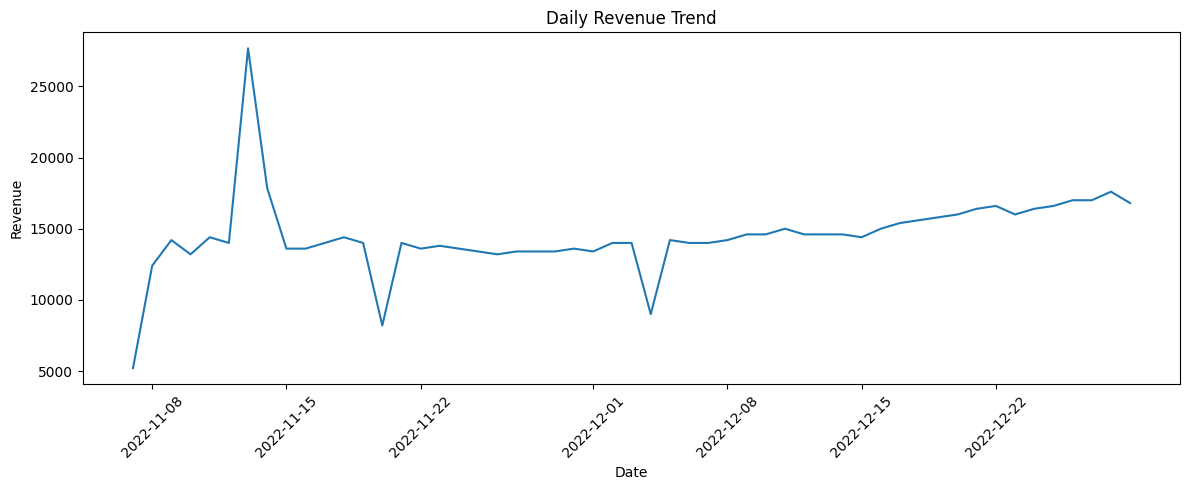

In [23]:
# ============================================================
# DAILY REVENUE TREND
# ============================================================

plt.figure(figsize=(12, 5))
plt.plot(daily_sales["Date"], daily_sales["Revenue"])
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# MONTHLY REVENUE
# ============================================================

monthly_revenue = (
    df.groupby(df["Date"].dt.to_period("M"))["Revenue"]
      .sum()
      .reset_index()
)

monthly_revenue["Date"] = monthly_revenue["Date"].dt.to_timestamp()

display(monthly_revenue)

,Date,Revenue
0,2022-11-01,332114.6584
1,2022-12-01,437401.2008


## Revenue Forecasting

We predict daily revenue using historical lag and calendar features.

To avoid leakage:
- lag features use only previous observations;
- the split is chronological, not random;
- the test period is kept untouched until evaluation.

In [25]:
# ============================================================
# TIME-SERIES FEATURES
# ============================================================

forecast_df = daily_sales.copy()

forecast_df["day_of_week"] = forecast_df["Date"].dt.dayofweek
forecast_df["day_of_month"] = forecast_df["Date"].dt.day
forecast_df["month"] = forecast_df["Date"].dt.month
forecast_df["is_weekend"] = (forecast_df["day_of_week"] >= 5).astype(int)

forecast_df["lag_1"] = forecast_df["Revenue"].shift(1)
forecast_df["lag_7"] = forecast_df["Revenue"].shift(7)

forecast_df["rolling_mean_7"] = (
    forecast_df["Revenue"].shift(1).rolling(7).mean()
)

feature_cols_revenue = [
    "day_of_week",
    "day_of_month",
    "month",
    "is_weekend",
    "lag_1",
    "lag_7",
    "rolling_mean_7"
]

model_data = forecast_df[
    feature_cols_revenue + ["Revenue"]
].dropna().reset_index(drop=True)

print("Daily observations:", len(forecast_df))
print("Model observations after lag features:", len(model_data))

display(model_data.head())

Daily observations: 53
Model observations after lag features: 46


,day_of_week,day_of_month,month,is_weekend,lag_1,lag_7,rolling_mean_7,Revenue
0,0,14,11,0,27674.4512,5200.0023,14439.239557,17839.3445
1,1,15,11,0,17839.3445,12400.0731,16244.859871,13600.0305
2,2,16,11,0,13600.0305,14200.0386,16416.282357,13600.0305
3,3,17,11,0,13600.0305,13200.0426,16330.566914,14000.0535
4,4,18,11,0,14000.0535,14400.0156,16444.854186,14400.1114


In [26]:
# ============================================================
# CHRONOLOGICAL TRAIN / TEST SPLIT
# ============================================================

if len(model_data) < 15:
    raise ValueError(
        f"Not enough daily observations after feature engineering: {len(model_data)}"
    )

split_idx = int(len(model_data) * 0.80)
split_idx = max(1, min(split_idx, len(model_data) - 1))

X = model_data[feature_cols_revenue]
y = model_data["Revenue"]

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

print("Train samples:", len(X_train))
print("Test samples :", len(X_test))
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

Train samples: 36
Test samples : 10
X_train: (36, 7)
X_test : (10, 7)


In [27]:
# ============================================================
# REVENUE FORECAST MODELS
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    actual = np.asarray(y_true)
    predicted = np.asarray(y_pred)
    mask = actual != 0

    if mask.any():
        mape = np.mean(
            np.abs((actual[mask] - predicted[mask]) / actual[mask])
        ) * 100
    else:
        mape = np.nan

    return mae, rmse, mape

revenue_models = {}

lr = LinearRegression()
lr.fit(X_train, y_train)
revenue_models["Linear Regression"] = lr

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
revenue_models["Random Forest"] = rf

try:
    from xgboost import XGBRegressor

    xgb = XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
    xgb.fit(X_train, y_train)
    revenue_models["XGBoost"] = xgb
except Exception as e:
    print("XGBoost unavailable; continuing with sklearn models.")

In [28]:
# ============================================================
# REVENUE MODEL COMPARISON
# ============================================================

revenue_results = []

for name, model in revenue_models.items():
    predictions = model.predict(X_test)
    mae, rmse, mape = regression_metrics(y_test, predictions)

    revenue_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    })

revenue_model_comparison = (
    pd.DataFrame(revenue_results)
      .sort_values("MAE")
      .reset_index(drop=True)
)

display(revenue_model_comparison)

best_revenue_model_name = revenue_model_comparison.iloc[0]["Model"]
best_revenue_model = revenue_models[best_revenue_model_name]

print("Best revenue model:", best_revenue_model_name)

,Model,MAE,RMSE,MAPE (%)
0,Linear Regression,610.145742,743.918243,3.642568
1,Random Forest,1373.228982,1550.738757,8.148906
2,XGBoost,1529.679980,1787.811334,9.053442


Best revenue model: Linear Regression


,Revenue,Predicted_Revenue
36,16000.0073,15869.134145
37,16399.9694,15886.705485
38,16599.9644,15998.527088
39,16000.0218,15867.608013
40,16399.9839,15260.493167
41,16599.9789,15208.674251
42,17000.0199,16660.463746
43,17000.0199,16618.322296
44,17599.9770,16479.157952
45,16800.0780,16449.476933


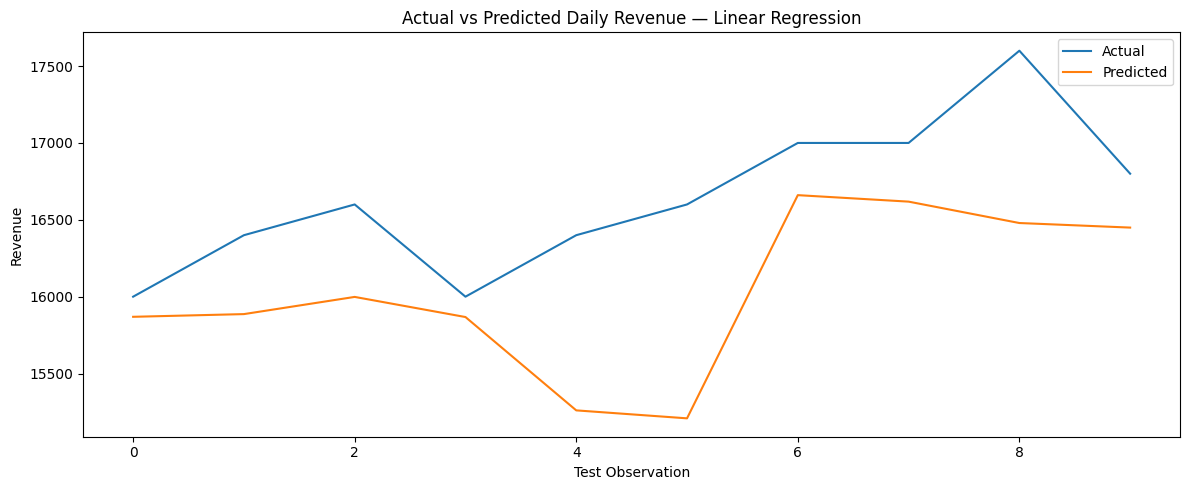

In [29]:
# ============================================================
# ACTUAL VS PREDICTED REVENUE
# ============================================================

best_predictions = best_revenue_model.predict(X_test)

test_revenue = model_data.iloc[split_idx:].copy()
test_revenue["Predicted_Revenue"] = best_predictions

display(
    test_revenue[
        ["Revenue", "Predicted_Revenue"]
    ].head(10)
)

plt.figure(figsize=(12, 5))
plt.plot(test_revenue["Revenue"].values, label="Actual")
plt.plot(test_revenue["Predicted_Revenue"].values, label="Predicted")
plt.title(f"Actual vs Predicted Daily Revenue — {best_revenue_model_name}")
plt.xlabel("Test Observation")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.show()

,Feature,Importance
2,month,1989.715337
3,is_weekend,430.566190
0,day_of_week,155.071314
1,day_of_month,92.240202
6,rolling_mean_7,0.339670
5,lag_7,0.312175
4,lag_1,0.062261


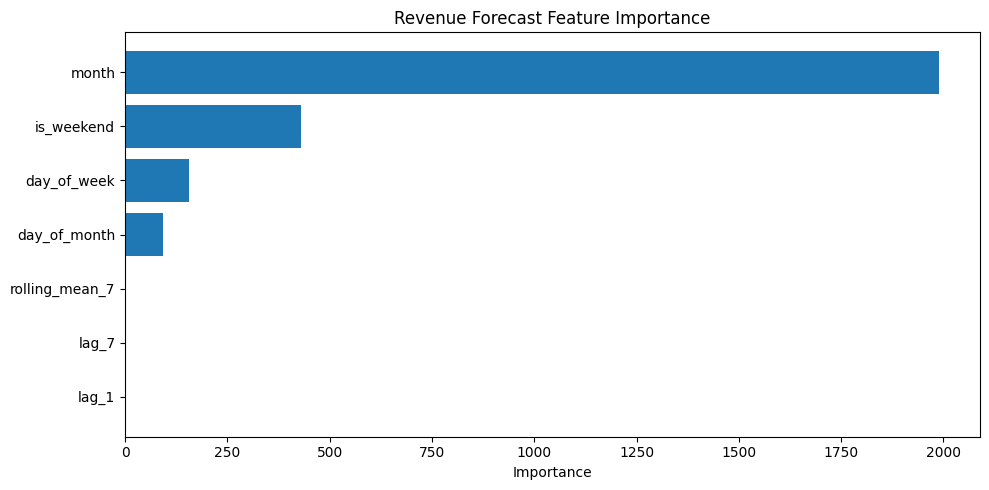

In [30]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

if hasattr(best_revenue_model, "feature_importances_"):
    importance = pd.DataFrame({
        "Feature": feature_cols_revenue,
        "Importance": best_revenue_model.feature_importances_
    }).sort_values("Importance", ascending=False)
else:
    importance = pd.DataFrame({
        "Feature": feature_cols_revenue,
        "Importance": np.abs(best_revenue_model.coef_)
    }).sort_values("Importance", ascending=False)

display(importance)

plt.figure(figsize=(10, 5))
plt.barh(importance["Feature"], importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Revenue Forecast Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Anomaly Detection

We use Isolation Forest to flag unusual daily business activity.
Because the dataset does not provide an anomaly ground-truth label,
the results are treated as exploratory signals rather than verified incidents.

In [31]:
# ============================================================
# DAILY SALES ANOMALY DETECTION
# ============================================================

from sklearn.ensemble import IsolationForest

anomaly_features = daily_sales[
    ["Revenue", "Quantity", "Transactions"]
].copy()

anomaly_model = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42
)

daily_sales["anomaly_score_label"] = anomaly_model.fit_predict(
    anomaly_features
)

daily_sales["Is_Anomaly"] = (
    daily_sales["anomaly_score_label"] == -1
)

anomalies = daily_sales[
    daily_sales["Is_Anomaly"]
].copy()

print("Anomalous days detected:", len(anomalies))
display(anomalies)

Anomalous days detected: 8


,Date,Revenue,Quantity,Transactions,anomaly_score_label,Is_Anomaly
0,2022-11-07,5200.0023,1519.23,3,-1,True
1,2022-11-08,12400.0731,1544.15,4,-1,True
3,2022-11-10,13200.0426,2006.32,4,-1,True
6,2022-11-13,27674.4512,2217.83,5,-1,True
13,2022-11-20,8200.0466,678.30,2,-1,True
27,2022-12-04,9000.1007,739.89,2,-1,True
51,2022-12-28,17599.9770,2533.88,5,-1,True
52,2022-12-29,16800.0780,2344.18,4,-1,True


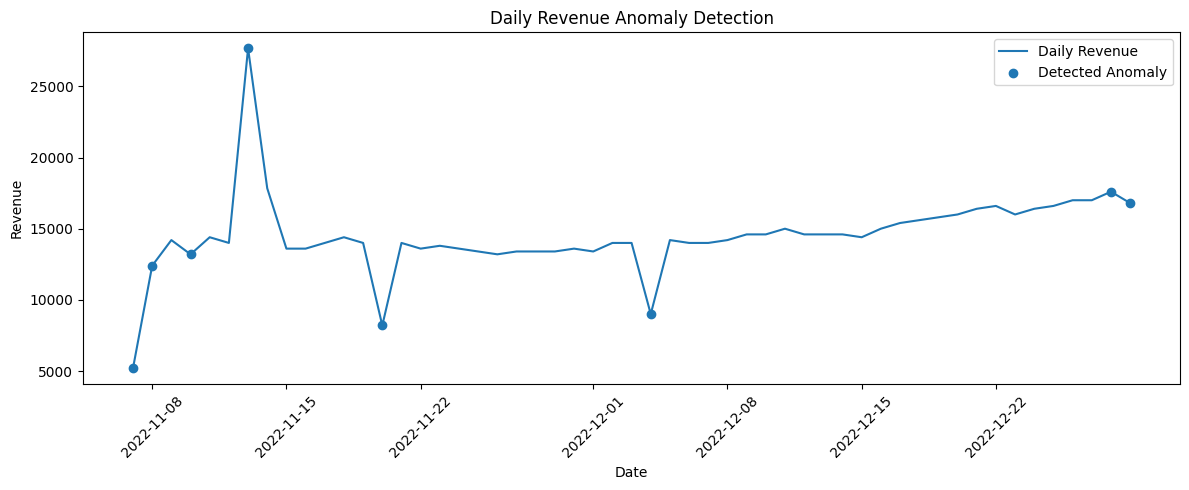

In [32]:
# ============================================================
# ANOMALY VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    daily_sales["Date"],
    daily_sales["Revenue"],
    label="Daily Revenue"
)

anomaly_points = daily_sales[daily_sales["Is_Anomaly"]]

if len(anomaly_points) > 0:
    plt.scatter(
        anomaly_points["Date"],
        anomaly_points["Revenue"],
        label="Detected Anomaly"
    )

plt.title("Daily Revenue Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## BizIntel AI Business Insight Dataset

These tables are the outputs we can later load into PostgreSQL.
They will become tools for the LangGraph business agent.

In [33]:
# ============================================================
# EXPORT DATA FOR NEXT BIZINTEL AI STAGES
# ============================================================

output_dir = "/kaggle/working/bizintel_outputs"
os.makedirs(output_dir, exist_ok=True)

df.to_csv(
    f"{output_dir}/cleaned_transactions.csv",
    index=False
)

daily_sales.to_csv(
    f"{output_dir}/daily_sales.csv",
    index=False
)

monthly_revenue.to_csv(
    f"{output_dir}/monthly_revenue.csv",
    index=False
)

revenue_model_comparison.to_csv(
    f"{output_dir}/revenue_model_metrics.csv",
    index=False
)

test_revenue.to_csv(
    f"{output_dir}/revenue_test_predictions.csv",
    index=False
)

anomalies.to_csv(
    f"{output_dir}/sales_anomalies.csv",
    index=False
)

importance.to_csv(
    f"{output_dir}/revenue_feature_importance.csv",
    index=False
)

print("Exported files:")
for filename in sorted(os.listdir(output_dir)):
    print("-", filename)

Exported files:
- cleaned_transactions.csv
- daily_sales.csv
- monthly_revenue.csv
- revenue_feature_importance.csv
- revenue_model_metrics.csv
- revenue_test_predictions.csv
- sales_anomalies.csv


## Final Notes

The original EDA/predictive-analysis workflow is retained, while the BizIntel layer adds:

- Revenue as a business KPI
- Daily and monthly revenue analysis
- Revenue forecasting with chronological validation
- Anomaly detection
- Business-ready CSV outputs

**Next project stage:** load these outputs into PostgreSQL, add synthetic business-policy documents for RAG, then build the LangGraph AI business agent.

## Visualizations for the data

/tmp/ipykernel_58/1489176353.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_5_expensive_products.index, x=top_5_expensive_products.values, palette='RdYlGn')


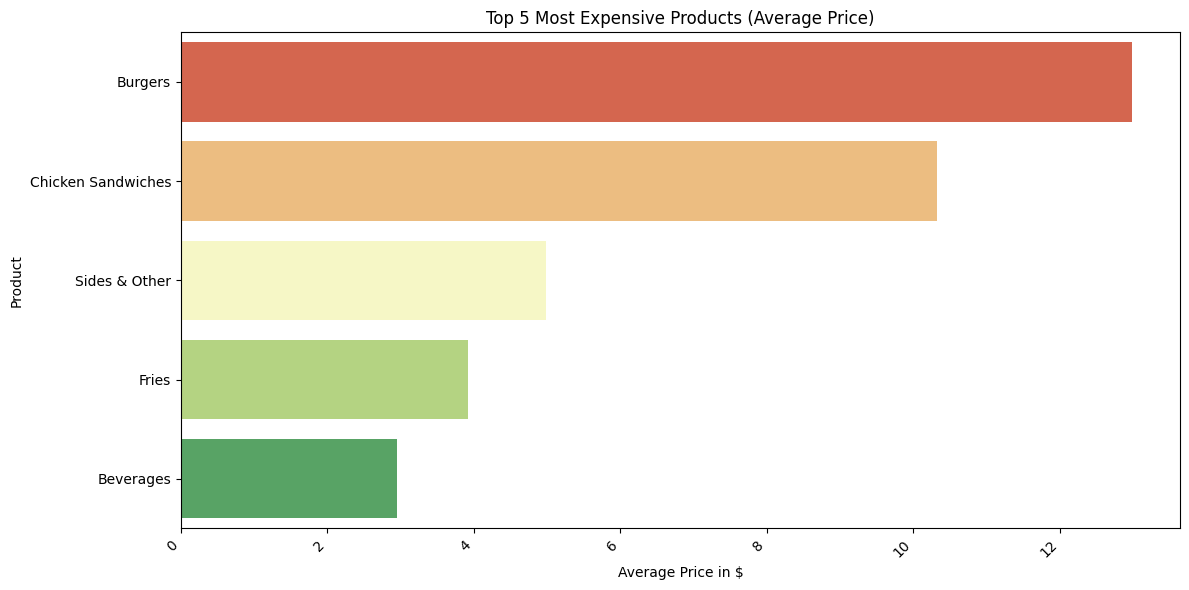

In [34]:
# Calculate the average price for each product
average_price_by_product = df.groupby('Product')['Price'].mean().sort_values(ascending=False)

# Select the top 10 most expensive products
top_5_expensive_products = average_price_by_product.head()

# Average of the most expensive products
plt.figure(figsize=(12, 6))
sns.barplot(y=top_5_expensive_products.index, x=top_5_expensive_products.values, palette='RdYlGn')
plt.title('Top 5 Most Expensive Products (Average Price)')
plt.xlabel('Average Price in $')
plt.ylabel('Product')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


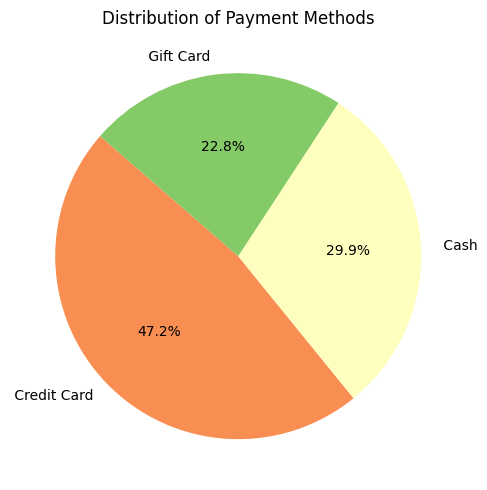

In [35]:
# Count the total of Payment Method
Total_Payment_Method = df['Payment Method'].value_counts(ascending=False)

#Payment method prefered
plt.figure(figsize=(5, 5))
plt.pie(Total_Payment_Method, labels=Total_Payment_Method.index, autopct='%1.1f%%', startangle=139, colors=sns.color_palette('RdYlGn', len(Total_Payment_Method)))
plt.title('Distribution of Payment Methods')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

/tmp/ipykernel_58/4228073939.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=total_quantity_by_product.values, y=total_quantity_by_product.index, palette='viridis')
/tmp/ipykernel_58/4228073939.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


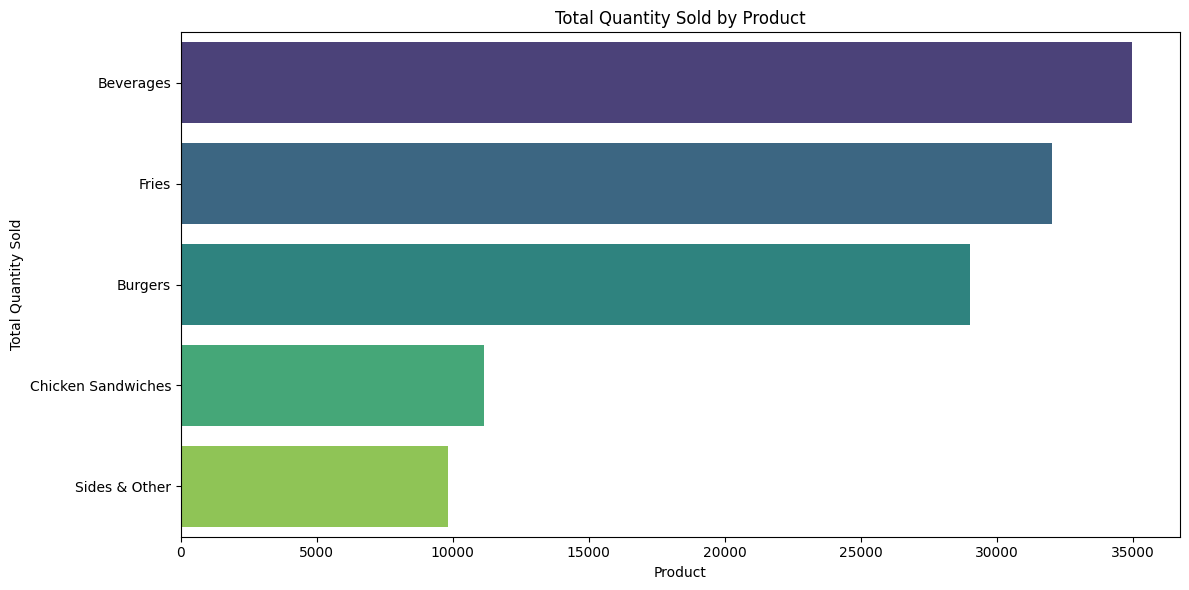

In [36]:
# Calculate the total quantity sold for each product
total_quantity_by_product = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)

# Quantity of products sold
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=total_quantity_by_product.values, y=total_quantity_by_product.index, palette='viridis')
plt.title('Total Quantity Sold by Product')
plt.xlabel('Product')
plt.ylabel('Total Quantity Sold')
plt.legend().remove()
plt.xticks(ha='center')
plt.tight_layout()

plt.show()

/tmp/ipykernel_58/1704824111.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_sales.index, y=city_sales.values, palette='viridis')
/tmp/ipykernel_58/1704824111.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


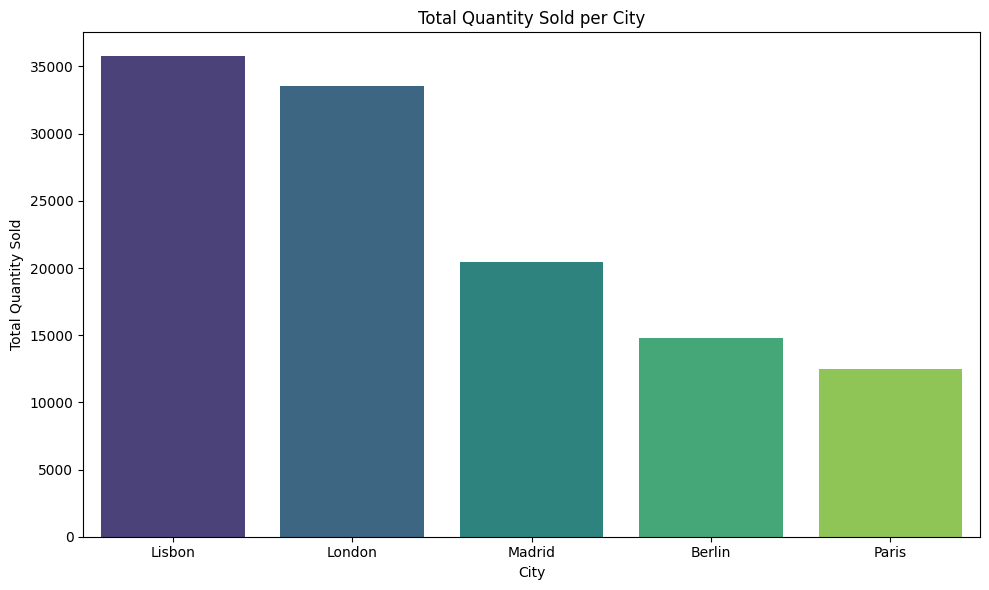

In [37]:
# Group by city and calculate the total quantity sold
city_sales = df.groupby('City')['Quantity'].sum().sort_values(ascending=False)

#Total Quantity sold of the cities
plt.figure(figsize=(10, 6))
sns.barplot(x=city_sales.index, y=city_sales.values, palette='viridis')
plt.title('Total Quantity Sold per City')
plt.xlabel('City')
plt.ylabel('Total Quantity Sold')
plt.legend().remove()
plt.xticks(ha='center')
plt.tight_layout()
plt.show()

/tmp/ipykernel_58/3388852358.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=manager_sales.values, y= manager_sales.index, palette='viridis')
/tmp/ipykernel_58/3388852358.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


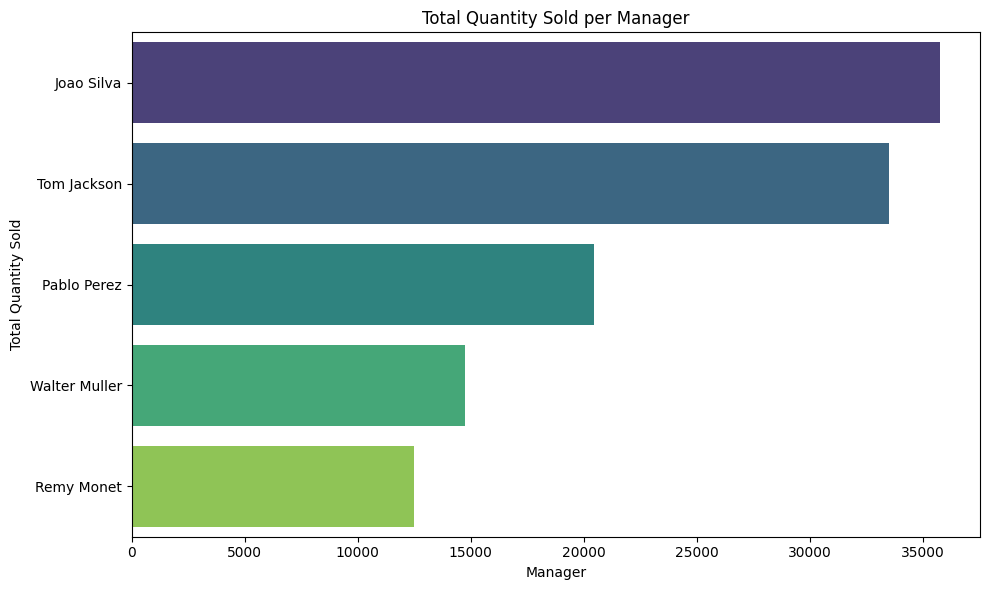

In [38]:
# Group by manager and calculate the total quantity sold
manager_sales = df.groupby('Manager')['Quantity'].sum().sort_values(ascending=False)

# Quantity sold by each Manager.
plt.figure(figsize=(10, 6))
sns.barplot(x=manager_sales.values, y= manager_sales.index, palette='viridis')
plt.title('Total Quantity Sold per Manager')
plt.xlabel('Manager')
plt.ylabel('Total Quantity Sold')
plt.legend().remove()
plt.xticks(ha='center')
plt.tight_layout()
plt.show()

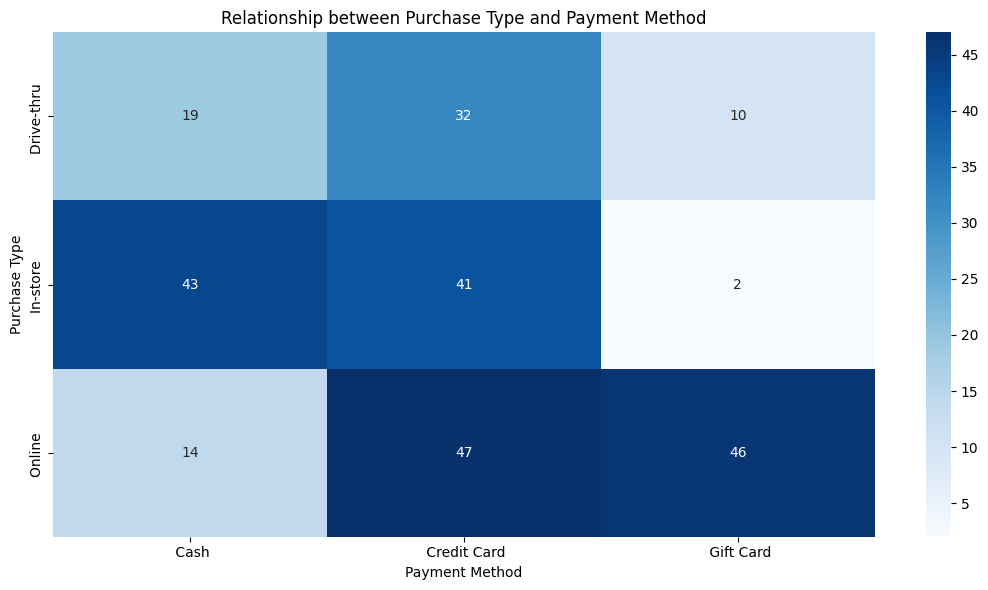

In [39]:
# Group by Purchase Type and Payment Method and count the occurrences
purchase_payment_counts = df.groupby(['Purchase Type', 'Payment Method']).size().unstack(fill_value=0)

# Create a heatmap
plt.figure(figsize=(11, 6))
sns.heatmap(purchase_payment_counts, annot=True, fmt='d', cmap='Blues')
plt.title('Relationship between Purchase Type and Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Purchase Type')
plt.tight_layout()
plt.show()

## Predictive Models

In [40]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [41]:
#Drop innecesary columns for the predictions
df.drop(columns=['Order ID', 'Date'], inplace=True)

In [42]:
#ONE-HOT ENCODING
# Select categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Apply one-hot encoding
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

display(df.head())

,Price,Quantity,Revenue,Product_Burgers,Product_Chicken Sandwiches,Product_Fries,Product_Sides & Other,Purchase Type_In-store,Purchase Type_Online,Payment Method_ Credit Card,Payment Method_ Gift Card,Manager_Pablo Perez,Manager_Remy Monet,Manager_Tom Jackson,Manager_Walter Muller,City_Lisbon,City_London,City_Madrid,City_Paris
0,3.49,573.07,2000.0143,False,False,True,False,False,True,False,True,False,False,True,False,False,True,False,False
1,2.95,745.76,2199.9920,False,False,False,False,False,True,False,True,True,False,False,False,False,False,True,False
2,4.99,200.40,999.9960,False,False,False,True,True,False,False,True,False,False,False,False,True,False,False,False
3,12.99,569.67,7400.0133,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,9.95,201.01,2000.0495,False,True,False,False,True,False,True,False,False,False,False,True,False,False,False,False


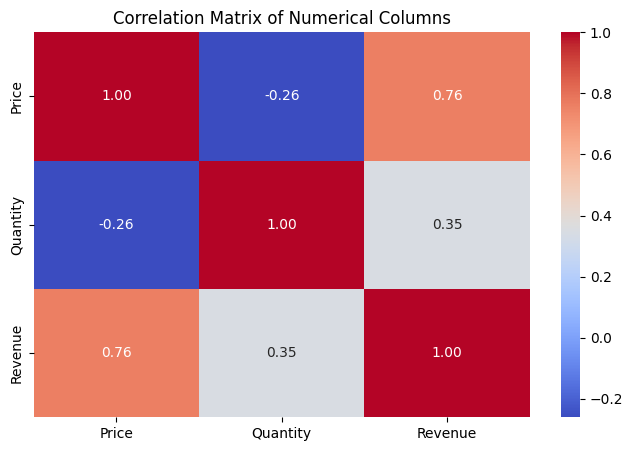

In [43]:
# Select only numerical columns for the correlation matrix
df_numerical = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = df_numerical.corr()

plt.figure(figsize=(8, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Columns')
plt.show()

In [44]:
#Divide in predictor and prediction.
X = df.drop(columns=['Quantity'])
y = df['Quantity']

In [45]:
#Identify categoric and numeric columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns
num_cols = X.select_dtypes(exclude=['object', 'category']).columns

In [46]:
#Define the models in a dictionary
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVM": SVR()
}

In [47]:
#Divide the information grabbing the 20% to test.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
# Save values in a list
train_scores = {}
test_scores = {}

# Train performance:
for name, model in models.items():
    model.fit(X_train, y_train)

    # Here are the predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate R²
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    train_scores[name] = r2_train
    test_scores[name] = r2_test

# Show results
print(f"{'Model':<20} {'R² Train':<10} {'R² Test':<10}")
for name in models:
    print(f"{name:<20} {train_scores[name]:<10.4f} {test_scores[name]:<10.4f}")


Model                R² Train   R² Test   
Decision Tree        1.0000     0.9980    
Linear Regression    0.9828     0.9914    
Random Forest        0.9986     0.9987    
KNN                  0.9716     0.8551    
SVM                  -0.0559    -0.0131   


In [49]:
#Cross-Validation results
print("\nCross-Validation results (5 folds):\n")
cv_results = {}  # Change cv_results to a dictionary
for name, model in models.items():
    pipe = Pipeline(steps=[('model', model)])
    scores = cross_val_score(pipe, X, y, cv=5, scoring='r2')
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    print(f"{name:<20} R2 mean: {mean_score:.4f} | std: {std_score:.4f}")
    cv_results[name] = {'R2 Mean': mean_score, 'R2 Std': std_score} # Store results in the dictionary


Cross-Validation results (5 folds):

Decision Tree        R2 mean: 0.9681 | std: 0.0378
Linear Regression    R2 mean: 0.8917 | std: 0.1683
Random Forest        R2 mean: 0.9873 | std: 0.0128
KNN                  R2 mean: 0.8142 | std: 0.2283
SVM                  R2 mean: -0.1560 | std: 0.1326


### Graphics of the Performance of the predictive models

Text(0.95, 0.05, 'R-squared: 0.89')

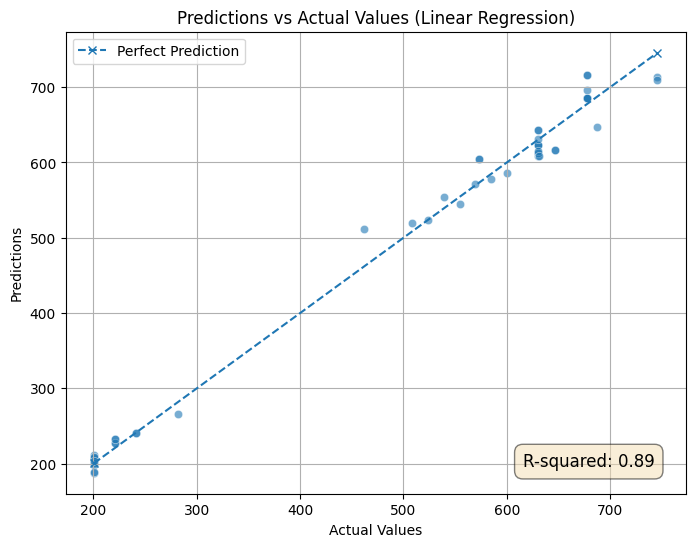

In [50]:
# Get the Linear Regression model and its predictions
linear_model = models['Linear Regression']
y_pred_lr = linear_model.predict(X_test)

# Get R-squared from the cross-validation list.
cv_result = cv_results['Linear Regression']['R2 Mean']

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--x', label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predictions')
plt.title('Predictions vs Actual Values (Linear Regression)')
plt.legend()
plt.grid(True)
plt.text(0.95, 0.05, f'R-squared: {cv_result:.2f}', transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))


Text(0.95, 0.05, 'R-squared: 0.97')

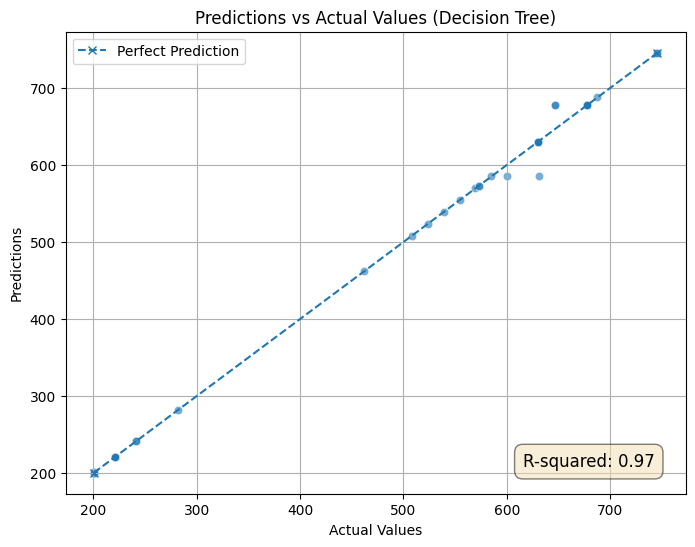

In [51]:
# Get the Decision Tree model and its predictions
dt_model = models['Decision Tree']
y_pred_dt = dt_model.predict(X_test)

# Get R-squared from the cross-validation list.
cv_result = cv_results['Decision Tree']['R2 Mean']

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_dt, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--x', label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predictions')
plt.title('Predictions vs Actual Values (Decision Tree)')
plt.legend()
plt.grid(True)
plt.text(0.95, 0.05, f'R-squared: {cv_result:.2f}', transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))


Text(0.95, 0.05, 'R-squared: 0.99')

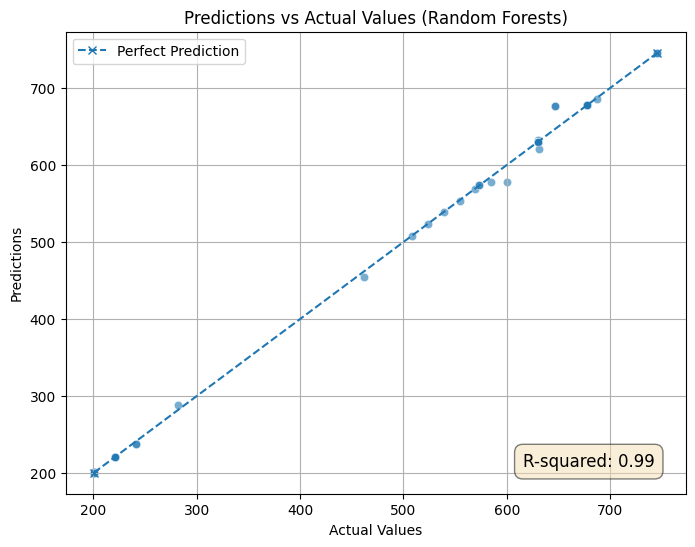

In [52]:
# Get the Decision Tree model and its predictions
dt_model = models['Random Forest']
y_pred_dt = dt_model.predict(X_test)

# Get R-squared from the cross-validation list.
cv_result = cv_results['Random Forest']['R2 Mean']

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_dt, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--x', label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predictions')
plt.title('Predictions vs Actual Values (Random Forests)')
plt.legend()
plt.grid(True)
plt.text(0.95, 0.05, f'R-squared: {cv_result:.2f}', transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))


Text(0.95, 0.05, 'R-squared: -0.16')

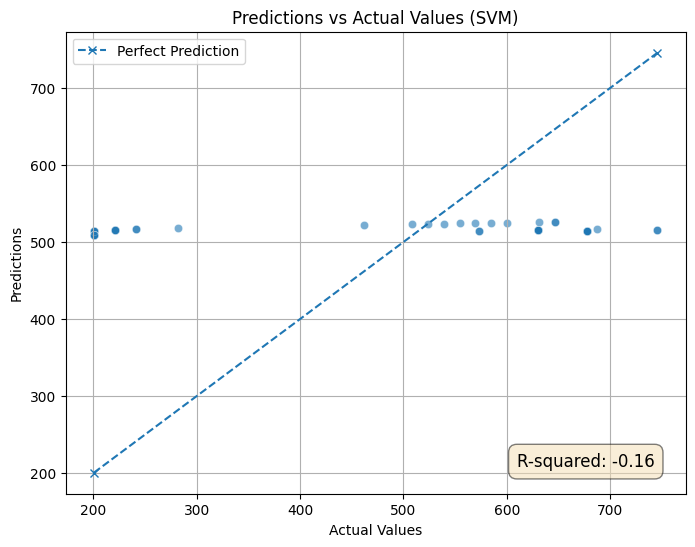

In [53]:
# Get the Decision Tree model and its predictions
dt_model = models['SVM']
y_pred_dt = dt_model.predict(X_test)

# Get R-squared from the cross-validation list.
cv_result = cv_results['SVM']['R2 Mean']

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_dt, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--x', label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predictions')
plt.title('Predictions vs Actual Values (SVM)')
plt.legend()
plt.grid(True)
plt.text(0.95, 0.05, f'R-squared: {cv_result:.2f}', transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))


Text(0.95, 0.05, 'R-squared: 0.81')

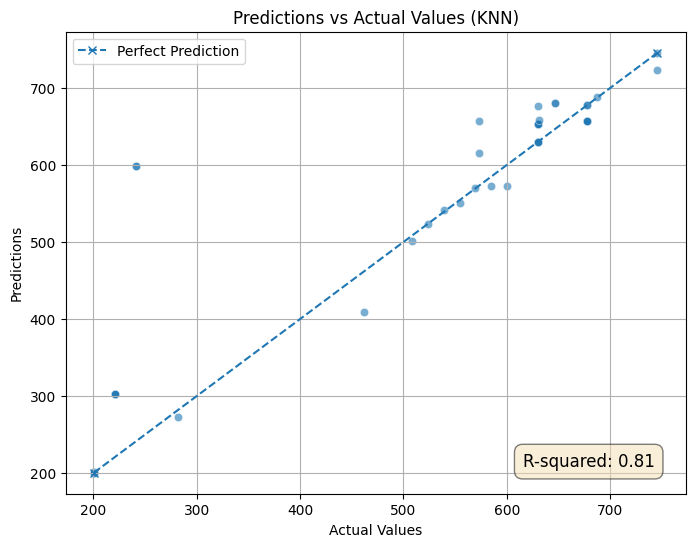

In [54]:
# Get the KNN model and its predictions
knn_model = models['KNN']
y_pred_knn = knn_model.predict(X_test)

# Get R-squared from the cross-validation list.
cv_result = cv_results['KNN']['R2 Mean']

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_knn, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--x', label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predictions')
plt.title('Predictions vs Actual Values (KNN)')
plt.legend()
plt.grid(True)
plt.text(0.95, 0.05, f'R-squared: {cv_result:.2f}', transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))


In [56]:
import os
import joblib

MODEL_DIR = "/kaggle/working/bizintel_models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Simpan model forecasting terbaik
# (best_revenue_model = revenue_models['Linear Regression'], target Revenue,
#  7 fitur time-series - inilah model yang menghasilkan
#  revenue_model_metrics.csv & revenue_test_predictions.csv)
joblib.dump(
    best_revenue_model,
    os.path.join(
        MODEL_DIR,
        "revenue_forecasting_linear_regression.joblib"
    )
)

print("Model berhasil disimpan:")
print(os.path.join(
    MODEL_DIR,
    "revenue_forecasting_linear_regression.joblib"
))

Model berhasil disimpan:
/kaggle/working/bizintel_models/revenue_forecasting_linear_regression.joblib


In [57]:
forecast_features = [
    "day_of_week",
    "day_of_month",
    "month",
    "is_weekend",
    "lag_1",
    "lag_7",
    "rolling_mean_7"
]

joblib.dump(
    forecast_features,
    os.path.join(MODEL_DIR, "forecast_features.joblib")
)

print("Feature configuration berhasil disimpan.")

Feature configuration berhasil disimpan.


In [60]:
joblib.dump(
    anomaly_model,
    os.path.join(
        MODEL_DIR,
        "revenue_anomaly_isolation_forest.joblib"
    )
)

print("Anomaly model berhasil disimpan.")

Anomaly model berhasil disimpan.


### Conclusions

## Graphic conclusions

- The average burgers are more expensive than the other food.
- The favorite Payment Method is credit card.
- The beverages were the product that was sold the most.
- Lisbon is the city that sold the most.
- Joao Silva is the manager that sold more quantity of products.
- Most of the people paid with credit card online.



## In prediction topic:


We can see that the best model for this dataset is the **Random Forest** for next reasons:

- 0.94 of determination coefficient (R2) so it explais the 94% of the variability of the data.
- 0.02 of standard variation, very precise.

This was done using the cross-validation technique to see how good the performance of the model is.

The **KNN**, **Decision Tree**, and even the **Linear Regression** are good models, but the random forest is better than them in this case. Maybe there are better models for this dataset, but i just wanted to try those five to see how it goes.

Thanks for looking at it and for your time! If there's a comment you would like to do or a thing I could do better or I did wrongs please feel free to tell me! I would love to learn more and be better with this kind of things.
I did this little proyect in google collab.